In [1]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

Saving weather.numeric.csv to weather.numeric.csv


In [2]:
weather_df = pd.read_csv(io.BytesIO(uploaded["weather.numeric.csv"]))
display(weather_df)

,Outlook,Temperature,Humidity,Windy,Play
0,sunny,85,85,False,no
1,sunny,80,90,True,no
2,overcast,83,86,False,yes
3,rainy,70,96,False,yes
4,rainy,68,80,False,yes
5,rainy,65,70,True,no
6,overcast,64,65,True,yes
7,sunny,72,95,False,no
8,sunny,69,70,False,yes
9,rainy,75,80,False,yes


In [3]:
weather_df["Outlook"].replace(to_replace=['sunny', 'overcast', 'rainy'], value=[1, 2, 3], inplace=True)
weather_df

,Outlook,Temperature,Humidity,Windy,Play
0,1,85,85,False,no
1,1,80,90,True,no
2,2,83,86,False,yes
3,3,70,96,False,yes
4,3,68,80,False,yes
5,3,65,70,True,no
6,2,64,65,True,yes
7,1,72,95,False,no
8,1,69,70,False,yes
9,3,75,80,False,yes


In [4]:
X = weather_df.drop(["Play"], axis = 1)
y = weather_df["Play"]

In [5]:
from sklearn.tree import DecisionTreeClassifier
clf_tree = DecisionTreeClassifier(criterion = 'entropy')
clf_tree.fit(X, y)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='entropy',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [6]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
y_hat = clf_tree.predict(X)

In [7]:
confusion_matrix(y, y_hat)

array([[5, 0],
       [0, 9]])

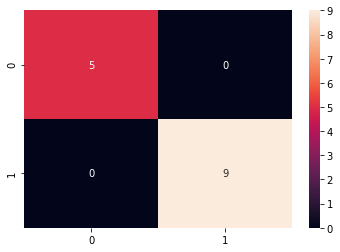

In [8]:
sns.heatmap(confusion_matrix(y, y_hat), annot = True, fmt='0.0f')

In [9]:
print(classification_report(y, y_hat))

              precision    recall  f1-score   support

          no       1.00      1.00      1.00         5
         yes       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



In [10]:
y.replace(to_replace=['no', 'yes'], value=[0, 1], inplace=True)
y

0     0
1     0
2     1
3     1
4     1
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    0
Name: Play, dtype: int64

/usr/local/lib/python3.7/dist-packages/sklearn/externals/six.py:31: FutureWarning: The module is deprecated in version 0.21 and will be removed in version 0.23 since we've dropped support for Python 2.7. Please rely on the official version of six (https://pypi.org/project/six/).
  "(https://pypi.org/project/six/).", FutureWarning)


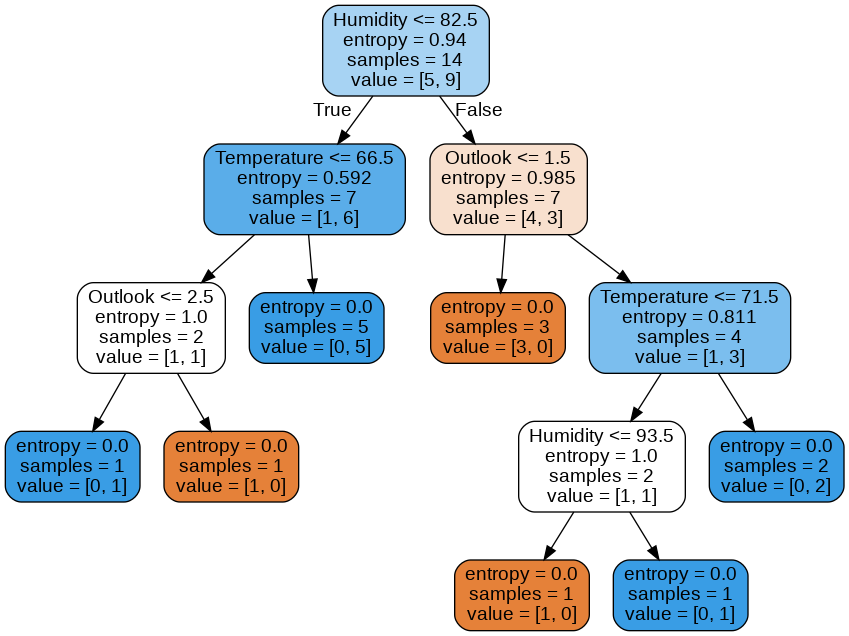

In [11]:
# Plotting Decision Tree
from sklearn.externals.six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(clf_tree, out_file= dot_data, feature_names= list(X.columns), filled = True, rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [12]:
# Print Text Representation
# Exporting Decision Tree to the text representation
from sklearn import tree
text_representation = tree.export_text(clf_tree)
print(text_representation)

|--- feature_2 <= 82.50
|   |--- feature_1 <= 66.50
|   |   |--- feature_0 <= 2.50
|   |   |   |--- class: yes
|   |   |--- feature_0 >  2.50
|   |   |   |--- class: no
|   |--- feature_1 >  66.50
|   |   |--- class: yes
|--- feature_2 >  82.50
|   |--- feature_0 <= 1.50
|   |   |--- class: no
|   |--- feature_0 >  1.50
|   |   |--- feature_1 <= 71.50
|   |   |   |--- feature_2 <= 93.50
|   |   |   |   |--- class: no
|   |   |   |--- feature_2 >  93.50
|   |   |   |   |--- class: yes
|   |   |--- feature_1 >  71.50
|   |   |   |--- class: yes



In [13]:
# If you want to save it to the file, it can be done with following code:
with open("decistion_tree.log", "w") as fout:
    fout.write(text_representation)

In [14]:
# https://mljar.com/blog/visualize-decision-tree/